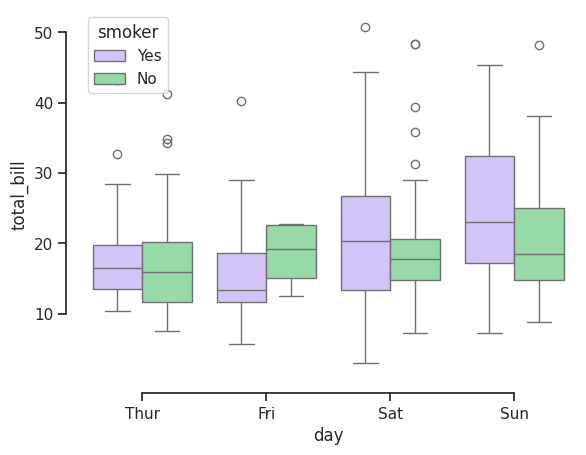

In [1]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

# Load the example tips dataset
tips = sns.load_dataset("tips")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="day", y="total_bill",
            hue="smoker", palette=["m", "g"],
            data=tips)
sns.despine(offset=10, trim=True)

# EDA(Exploratory Data Analysis)

In [2]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [3]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df=tips
# df=tips.copy()

In [19]:
#df=tips
df=tips.copy()

### Univariate Analysis: Categorical Data

Let's visualize the distribution of our categorical features: `sex`, `smoker`, `day`, and `time` using count plots.

TypeError: Data source must be a DataFrame or Mapping, not <class 'str'>.

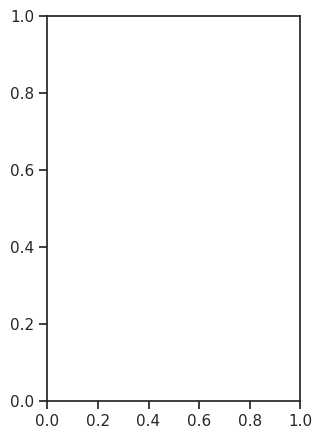

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
sns.countplot(x='sex', data=df, palette='viridis')
plt.title('Distribution of Sex')

plt.subplot(1, 4, 2)
sns.countplot(x='smoker', data=df, palette='viridis')
plt.title('Distribution of Smoker')

plt.subplot(1, 4, 3)
sns.countplot(x='day', data=df, palette='viridis')
plt.title('Distribution of Day')

plt.subplot(1, 4, 4)
sns.countplot(x='time', data=df, palette='viridis')
plt.title('Distribution of Time')

plt.tight_layout()
plt.show()

### Univariate Analysis: Numerical Data

Now, let's look at the distributions of numerical features: `total_bill`, `tip`, `size`, and the calculated `tip_pct` using histograms and KDE plots.

TypeError: string indices must be integers, not 'str'

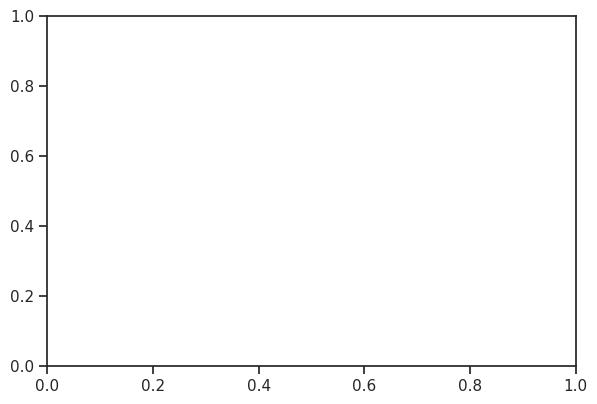

In [40]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(df['total_bill'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Total Bill')

plt.subplot(2, 2, 2)
sns.histplot(df['tip'], kde=True, bins=20, color='lightcoral')
plt.title('Distribution of Tip')

plt.subplot(2, 2, 3)
sns.histplot(df['size'], kde=False, bins=df['size'].nunique(), color='lightgreen')
plt.title('Distribution of Size')

plt.subplot(2, 2, 4)
sns.histplot(df['tip_pct'], kde=True, bins=20, color='gold')
plt.title('Distribution of Tip Percentage')

plt.tight_layout()
plt.show()

### Multivariate Analysis: Two Variables

Let's explore the relationships between different variables. We'll start with numerical vs. numerical, and then categorical vs. numerical.

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_bill', y='tip', hue='smoker', style='time', data=df, palette='deep')
plt.title('Total Bill vs. Tip by Smoker and Time')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'str'>.

<Figure size 1000x600 with 0 Axes>

In [42]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='day', y='total_bill', hue='sex', data=df, palette='pastel')
plt.title('Total Bill by Day and Sex')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'str'>.

<Figure size 1200x600 with 0 Axes>

In [43]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='time', y='tip_pct', hue='smoker', data=df, palette='muted', inner='quartile')
plt.title('Tip Percentage by Time and Smoker')
plt.xlabel('Time of Day')
plt.ylabel('Tip Percentage (%)')
plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'str'>.

<Figure size 1200x600 with 0 Axes>

In [44]:
df_high_tip = df[df['tip'] / df['total_bill'] >= 0.20]
display(df_high_tip.head())

TypeError: string indices must be integers, not 'str'

In [10]:
df['tip'] / df['total_bill']

,0
0,0.059447
1,0.160542
2,0.166587
3,0.139780
4,0.146808
...,...
239,0.203927
240,0.073584
241,0.088222
242,0.098204


In [13]:
df['tip'] / df['total_bill']*100

,0
0,5.944673
1,16.054159
2,16.658734
3,13.978041
4,14.680765
...,...
239,20.392697
240,7.358352
241,8.822232
242,9.820426


In [7]:
%whos

Variable   Type         Data/Info
---------------------------------
df         DataFrame         total_bill   tip    <...>n\n[244 rows x 7 columns]
sns        module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
tips       DataFrame         total_bill   tip    <...>n\n[244 rows x 7 columns]


In [15]:
df['tip_pct']=(df['tip'] / df['total_bill'])*100
df

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


In [16]:
df[df['tip_pct']>=20]

,total_bill,tip,sex,smoker,day,time,size,tip_pct
6,8.77,2.00,Male,No,Sun,Dinner,2,22.805017
9,14.78,3.23,Male,No,Sun,Dinner,2,21.853857
14,14.83,3.02,Female,No,Sun,Dinner,2,20.364127
17,16.29,3.71,Male,No,Sun,Dinner,3,22.774708
18,16.97,3.50,Female,No,Sun,Dinner,3,20.624632
20,17.92,4.08,Male,No,Sat,Dinner,2,22.767857
42,13.94,3.06,Male,No,Sun,Dinner,2,21.951220
46,22.23,5.00,Male,No,Sun,Dinner,2,22.492128
51,10.29,2.60,Female,No,Sun,Dinner,2,25.267250
63,18.29,3.76,Male,Yes,Sat,Dinner,4,20.557682


In [17]:
tips

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


In [26]:
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


In [29]:
df.groupby('day')['tip'].describe()

/tmp/ipykernel_2528/3048255687.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['tip'].describe()


,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,2.771452,1.240223,1.25,2.0000,2.305,3.3625,6.70
Fri,19.0,2.734737,1.019577,1.00,1.9600,3.000,3.3650,4.73
Sat,87.0,2.993103,1.631014,1.00,2.0000,2.750,3.3700,10.00
Sun,76.0,3.255132,1.234880,1.01,2.0375,3.150,4.0000,6.50


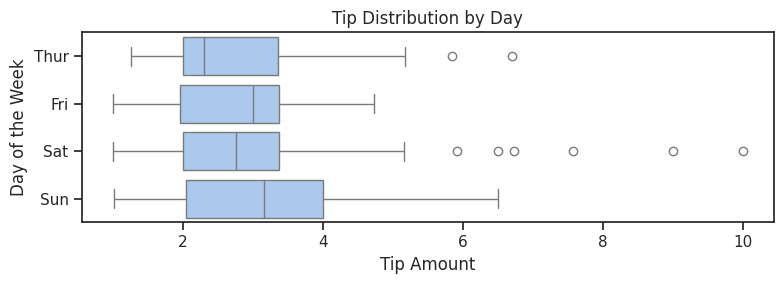

In [30]:
# 이변량
plt.figure(figsize=(8, 3))
sns.boxplot(data=df, x='tip', y='day')
plt.title("Tip Distribution by Day")
plt.xlabel("Tip Amount")
plt.ylabel("Day of the Week")
plt.tight_layout()
plt.show()

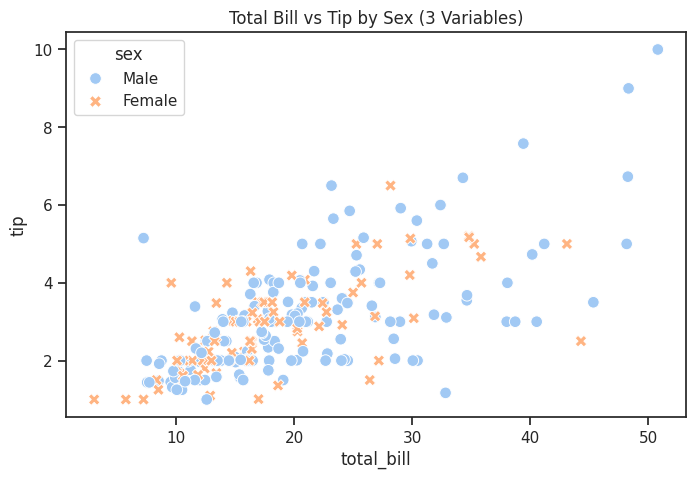

In [31]:
# 다변량
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='sex', style='sex', s=70)
plt.title("Total Bill vs Tip by Sex (3 Variables)")
plt.show()

### 지도를 그려서 median_house_value/population별로 scatter하여 어느 지역의 집값이 비싼지 말하시오(시각화도 하시오).

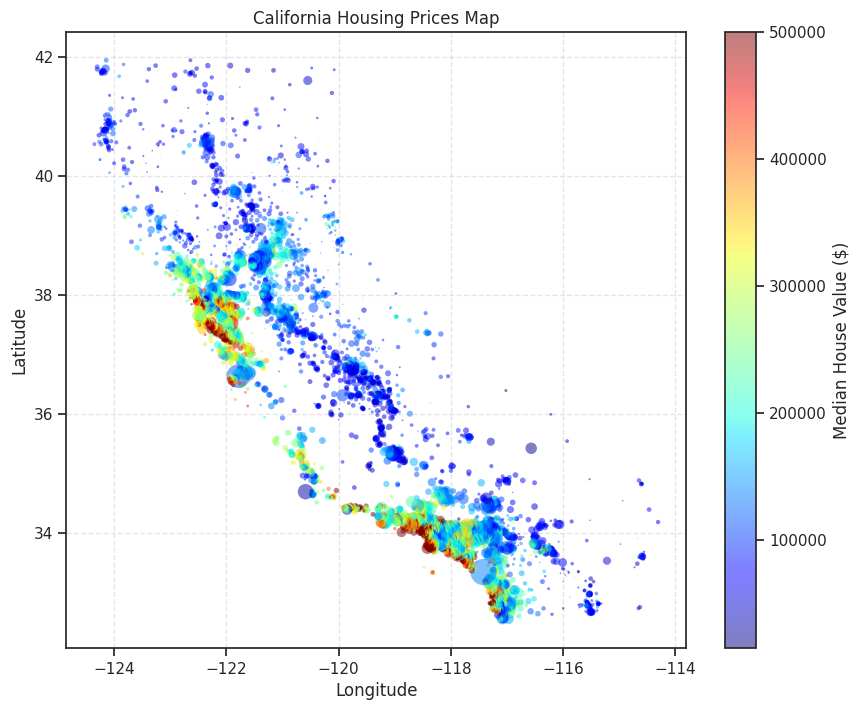

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

file_path='/content/sample_data/california_housing_train.csv'
df=pd.read_csv(file_path)

plt.figure(figsize=(10, 8))

scatter=plt.scatter(
    df['longitude'],
    df['latitude'],
    c=df['median_house_value'],
    cmap='jet',
    s=df['population']/100,
    alpha=0.5,
    edgecolors='none'
)

plt.colorbar(scatter, label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices Map')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 위 데이터에 대한 자신은 어떤 요일에 가서 손님을 대접하고 싶은지 생각을 적으시오.

나는 비흡연자이고, 건강을 위하여 일요일 저녁시간대 비흡연 남성, 여성들을 접대할 것이다.

## Questions: 가장 많은 Tip을 받으려면 어떤 요일, 시간대? 어떤 유형의 손님에게 하여야 하나?

정답: 일요일, 저녁시간대 흡연 남성분들의 손님.

In [57]:
df = tips.copy()
print("=== 요일별 평균 Tip ===")
print(df.groupby('day')['tip'].mean().sort_values(ascending=False))

print("\n=== 시간대별 평균 Tip ===")
print(df.groupby('time')['tip'].mean().sort_values(ascending=False))

print("\n=== 성별별 평균 Tip ===")
print(df.groupby('sex')['tip'].mean().sort_values(ascending=False))

print("\n=== 흡연 여부별 평균 Tip ===")
print(df.groupby('smoker')['tip'].mean().sort_values(ascending=False))

print("\n=== 식사 인원(size)별 평균 Tip ===")
print(df.groupby('size')['tip'].mean().sort_values(ascending=False))

=== 요일별 평균 Tip ===
day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

=== 시간대별 평균 Tip ===
time
Dinner    3.102670
Lunch     2.728088
Name: tip, dtype: float64

=== 성별별 평균 Tip ===
sex
Male      3.089618
Female    2.833448
Name: tip, dtype: float64

=== 흡연 여부별 평균 Tip ===
smoker
Yes    3.008710
No     2.991854
Name: tip, dtype: float64

=== 식사 인원(size)별 평균 Tip ===
size
6    5.225000
4    4.135405
5    4.028000
3    3.393158
2    2.582308
1    1.437500
Name: tip, dtype: float64


/tmp/ipykernel_2528/2502090599.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('day')['tip'].mean().sort_values(ascending=False))
/tmp/ipykernel_2528/2502090599.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('time')['tip'].mean().sort_values(ascending=False))
/tmp/ipykernel_2528/2502090599.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('sex')['tip'].mean().